In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

# data path
dataset_path = "C:/Users/Barka/.cache/kagglehub/datasets/rtatman/british-birdsong-dataset/versions/2"

## Load Dataset ##

In [3]:
birdsong_metadata = pd.read_csv(os.path.join(dataset_path,"birdsong_metadata.csv"))

In [4]:
birdsong_metadata["english_cname"]

0        Common Redpoll
1        Common Redpoll
2        Common Redpoll
3         Marsh Warbler
4         Marsh Warbler
             ...       
259         Song Thrush
260         Song Thrush
261    Northern Lapwing
262    Northern Lapwing
263    Northern Lapwing
Name: english_cname, Length: 264, dtype: str

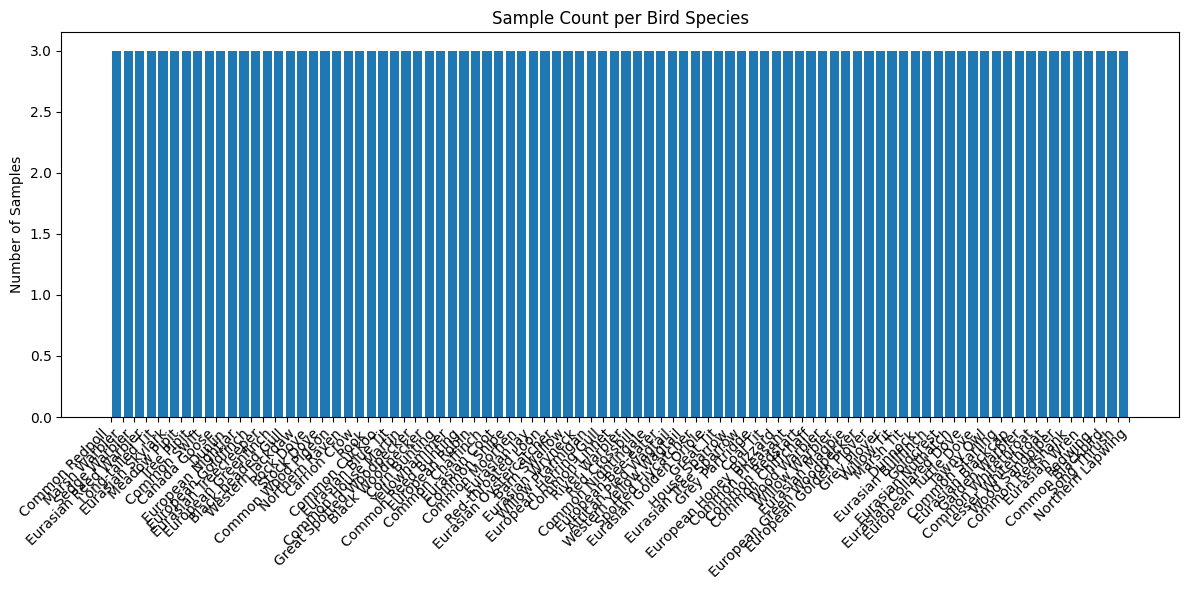

In [39]:
plt.figure(figsize=(12, 6))  # Make the window wider
plt.hist(birdsong_metadata["english_cname"], bins=len(set(birdsong_metadata["english_cname"])), rwidth=0.8)

# The Magic Trick: Rotate the text and align it nicely
plt.xticks(rotation=45, ha='right') 

plt.title('Sample Count per Bird Species')
plt.ylabel('Number of Samples')
plt.tight_layout()  # Ensures labels aren't cut off at the bottom
plt.show()

In [52]:
audio_filenames = [os.path.join(dataset_path, "songs/songs/xc"+str(file_id)+".FLAC") for file_id in birdsong_metadata["file_id"]]
durations = [librosa.get_duration(path=filename) for filename in audio_filenames];
sample_rates = [librosa.get_samplerate(path=filename) for filename in audio_filenames];
# y, sr = librosa.load(filename, sr=None) # sr=None preserves original sampling rate

# # 2. Extract a Mel-scaled Spectrogram (Crucial for bird calls)
# S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)

# # Convert to log scale (decibels) because human/animal hearing is logarithmic
# S_dB = librosa.power_to_db(S, ref=np.max)

# # 3. Visualize
# plt.figure(figsize=(10, 4))
# librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
# plt.colorbar(format='%+2.0f dB')
# plt.title('Mel-Spectrogram of Bird Call')
# plt.tight_layout()
# plt.show()

Text(0.5, 1.0, 'Histogram of file durations')

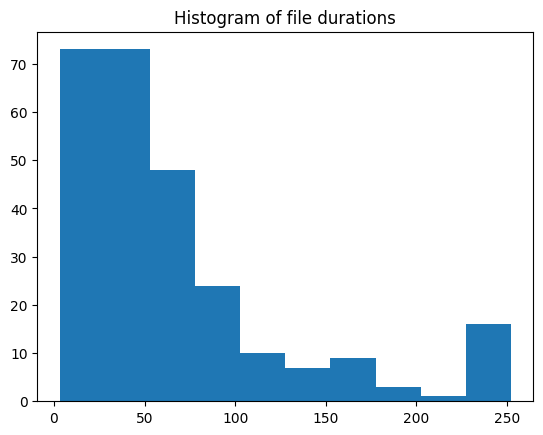

In [56]:
plt.hist(durations)
plt.title("Histogram of file durations")

## Processing the Data ##

The audio files have a wide range of durations making it difficult for a VAE model to acurately reconstruct data from the latent embeddings. To fix this the data is divided into uniform chunks that can be fed to the model. This is an acceptable compromise because most bird songs are short and do not change significantly between ~5 second intervals.

In [8]:
def audio_to_chunks(file_path, chunk_duration=5, sr=22050):
    keep_chunk_threshold = 0.5; # 50% of chunk must be filled
    chunk_samples = chunk_duration * sr 

    y, original_sr = librosa.load(file_path, sr=sr)
    total_samples = len(y)
    
    chunks = []
    
    # If the audio is shorter thank the chunk duration it gets padded
    if total_samples < chunk_samples:
        padded_y = librosa.util.fix_length(y, size=chunk_samples)
        chunks.append(padded_y)
    else:
        # divide into chunks
        for start in range(0, total_samples, chunk_samples):
            end = start + chunk_samples
            chunk = y[start:end]
            
            # if the left over data is more than 50% of chunk duration then pad it
            if len(chunk) < chunk_samples:
                if(len(chunk) < chunk_samples * keep_chunk_threshold):
                    break;
                chunk = librosa.util.fix_length(chunk, size=chunk_samples)
            chunks.append(chunk)
            
    return chunks

def process_file(file_id):
    file_path = os.path.join(dataset_path, "songs/songs/xc"+str(file_id)+".FLAC");
    chunks = audio_to_chunks(file_path);
    filenames = []
    
    for index, chunk in enumerate(chunks):
        # create spectrogram MEL scaled
        S = librosa.feature.melspectrogram(y=chunk, sr=22050, n_mels=128)
        # scale logarithmically
        S_dB = librosa.power_to_db(S, ref=np.max)

        # convert to pytorch tensor for model
        chunk_data = torch.tensor(S_dB, dtype=torch.float32).unsqueeze(0)
        
        torch.save(chunk_data, f'./processed_spectrograms/{file_id}_chunk_{index}.pt')
        filenames.append(f'./processed_spectrograms/{file_id}_chunk_{index}.pt');
    return filenames;

Save all the data as PyTorch tensors along with a metadata file containing labels for latent space visualization.

In [19]:
chunk_filenames = [];
chunk_labels = [];

for index, file_id in enumerate(birdsong_metadata["file_id"]):
    print(f'processing file: #{index}, name: {birdsong_metadata["english_cname"][index]}');

    filenames = process_file(file_id);

    # update meta data for labeling
    chunk_filenames += filenames;
    chunk_labels += [birdsong_metadata["english_cname"][index] for i in range(len(filenames))]

metadata = {
    "filenames": chunk_filenames,
    "labels": chunk_labels
}

df = pd.DataFrame(metadata);
df.to_csv("metadata.csv", index=False);

processing file: #0, name: Common Redpoll
processing file: #1, name: Common Redpoll
processing file: #2, name: Common Redpoll
processing file: #3, name: Marsh Warbler
processing file: #4, name: Marsh Warbler
processing file: #5, name: Marsh Warbler
processing file: #6, name: Sedge Warbler
processing file: #7, name: Sedge Warbler
processing file: #8, name: Sedge Warbler
processing file: #9, name: Eurasian Reed Warbler
processing file: #10, name: Eurasian Reed Warbler
processing file: #11, name: Eurasian Reed Warbler
processing file: #12, name: Long-tailed Tit
processing file: #13, name: Long-tailed Tit
processing file: #14, name: Long-tailed Tit
processing file: #15, name: Eurasian Skylark
processing file: #16, name: Eurasian Skylark
processing file: #17, name: Eurasian Skylark
processing file: #18, name: Meadow Pipit
processing file: #19, name: Meadow Pipit
processing file: #20, name: Meadow Pipit
processing file: #21, name: Tree Pipit
processing file: #22, name: Tree Pipit
processing 